<a href="https://colab.research.google.com/github/Akritz2004/ProjectStock-Energy-Banking-Retail-/blob/main/StockProject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
!pip install yfinance
!pip install pandas_ta
!pip install --upgrade scikit-learn scipy

  Using cached scipy-1.17.1-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (62 kB)
Using cached scipy-1.17.1-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (35.2 MB)


In [5]:
import pandas as pd
import pandas_ta as ta
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt


In [6]:
interesting_tickers = ["PTT.BK", "CPALL.BK", "KBANK.BK"]
df = yf.download(interesting_tickers, period="5y")['Close']

/tmp/ipykernel_13665/1839076495.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(interesting_tickers, period="5y")['Close']
[*********************100%***********************]  3 of 3 completed


In [7]:
df

Ticker,CPALL.BK,KBANK.BK,PTT.BK
Date,,,
2021-04-12,58.885822,111.999977,28.830696
2021-04-16,59.116745,108.765327,29.385130
2021-04-19,59.347668,110.786987,29.385130
2021-04-20,60.040447,115.317329,29.385130
2021-04-21,59.347668,115.317329,29.015503
...,...,...,...
2026-04-03,45.500000,190.500000,34.250000
2026-04-07,45.250000,191.500000,34.750000
2026-04-08,47.250000,193.000000,35.000000


In [8]:
##การเปลี่ยนแปลงรายวัน
returns_df = df.pct_change().dropna()
returns_df

Ticker,CPALL.BK,KBANK.BK,PTT.BK
Date,,,
2021-04-16,0.003922,-0.028881,0.019231
2021-04-19,0.003906,0.018587,0.000000
2021-04-20,0.011673,0.040892,0.000000
2021-04-21,-0.011539,0.000000,-0.012579
2021-04-22,-0.011673,-0.021429,-0.006369
...,...,...,...
2026-04-03,0.000000,-0.007812,-0.035211
2026-04-07,-0.005495,0.005249,0.014599
2026-04-08,0.044199,0.007833,0.007194


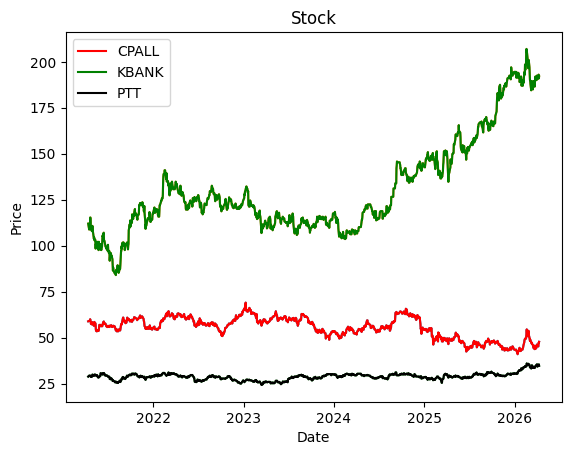

In [9]:
plt.plot(df)
plt.plot(df['CPALL.BK'], label='CPALL', color = 'red')
plt.plot(df['KBANK.BK'], label='KBANK',color = 'green')
plt.plot(df['PTT.BK'], label='PTT', color = 'black')
plt.title('Stock')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.show()

###หมายเหตุ หากค่าเปลี่ยนไปจากเดิม เหตุผลมาจากการที่โหลดข้อมูลแบบ Realtime พอรันใหม่ทำให้เลขเปลี่ยนไปเรื่อยๆ

หากสังเกตุราคา น้ำมันของ PTT ดีๆ จะเห็นว่ามีการเพิ่มสูงขึ้นกว่า 4ปี ที่ผ่านมา เนื่องจากอยู่ในช่วงสภาวะสงครามทำให้เราสังเกตุเห็นได้ง่าย และอาจเป็นตัวแปรที่ส่งผลต่อหุ้นตัวอื่นๆ เนื่องจากน้ำมันเป็นสิ่งสำคัญ ในการดำเนินธุรกิจต่างๆ

###สนใจหุ้น PTT

In [10]:
df_ptt_full = yf.download("PTT.bk", period="5y")
df_ptt_full = df_ptt_full.xs('PTT.BK', axis=1, level=1)
df_ptt_full

/tmp/ipykernel_13665/3029425550.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df_ptt_full = yf.download("PTT.bk", period="5y")
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Date,,,,,
2021-04-12,28.830694,29.200318,28.645882,29.015506,37609500
2021-04-16,29.385130,29.569942,29.015506,29.200318,60260500
2021-04-19,29.385130,29.569942,29.200318,29.385130,30128300
2021-04-20,29.385130,29.754754,29.200318,29.385130,34410000
2021-04-21,29.015507,29.200319,28.830695,29.200319,40084200
...,...,...,...,...,...
2026-04-03,34.250000,35.500000,34.250000,35.500000,96794300
2026-04-07,34.750000,35.250000,34.000000,34.250000,90396600
2026-04-08,35.000000,35.250000,34.250000,34.500000,73033000


<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

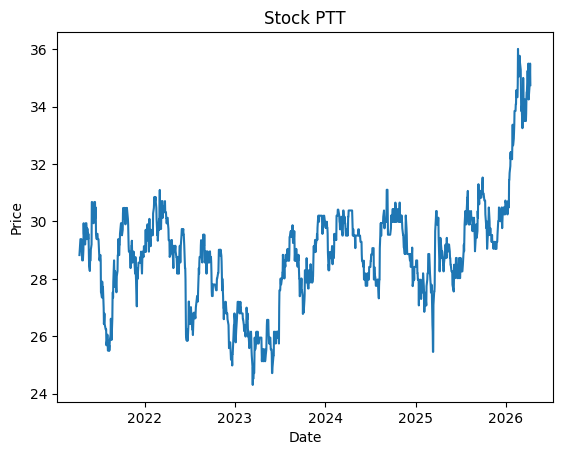

In [11]:
plt.plot(df_ptt_full['Close'])
plt.title('Stock PTT')
plt.xlabel('Date')
plt.ylabel('Price')
plt

In [12]:
print(df_ptt_full['Volume'].head())

Date
2021-04-12    37609500
2021-04-16    60260500
2021-04-19    30128300
2021-04-20    34410000
2021-04-21    40084200
Name: Volume, dtype: int64


จากกราฟช่วงก่อน 2022 มีราคาหุ้นที่ปกติ แต่เนนื่องจากในปี 2026 เกิดสภาวะสงคราม และสภาพเศรฐกิจ ทำให้ราคาเกิดการผันผวน

กำหนด Y = ราคาขึ้นหรือลง ขึ้นคือ 1 ลงหรือเท่าเดิมคือ 0
กำหนด X = RSI,MACD, MA, Volume, Volatility

*   RSI (Relative Strength Index) คือ เครื่องมือทางเทคนิคที่ใช้วัด "ความแข็งแกร่ง" ของราคาหุ้นหรือสินทรัพย์ เพื่อดูว่ามีการซื้อมากเกินไป (Overbought) หรือขายมากเกินไป (Oversold)
*   MACD (Moving Average Convergence Divergence) คือ เครื่องมือทางเทคนิคที่ช่วยดู ทิศทางแนวโน้ม (Trend) และ แรงส่งของราคา (Momentum)

*   MA (Moving Average) หรือ SMA 20 (Simple Moving Average 20) คือ เครื่องมือทางเทคนิคที่นำราคาปิดย้อนหลังมาหาค่าเฉลี่ย เพื่อทำให้กราฟหุ้นดูเรียบเนียนขึ้น ตัดความผันผวนระหว่างวันออกไป ช่วยให้มองเห็น "แนวโน้ม (Trend)" ชัดเจนว่าหุ้นเป็นขาขึ้น ขาลง หรือออกข้าง นิยมใช้ดูแนวรับ-แนวต้าน และสัญญาณซื้อ-ขาย
*   Volume คือ ปริมาณการซื้อขาย คือจำนวนหุ้น (หรือสัญญา) ทั้งหมดที่มีการจับคู่ซื้อขายกันจริงในช่วงเวลาหนึ่งๆ เป็นดัชนีชี้วัดความสนใจของนักลงทุน หาก Volume สูงแปลว่าคนกำลังสนใจหุ้นตัวนั้นมาก หากต่ำแปลว่าคนสนใจน้อย โดยมักดูควบคู่กับราคาร่วมกับกราฟเทคนิคเพื่อวิเคราะห์แนวโน้ม
*   Volatility คือ ตัวชี้วัดว่าราคาสินทรัพย์ (เช่น หุ้น, ทองคำ, คริปโต) มีการแกว่งตัวขึ้นลงเร็วและแรงแค่ไหนในช่วงเวลาหนึ่ง ยิ่งราคาเคลื่อนไหวแรงและบ่อย แปลว่ามีความผันผวนสูง (เสี่ยงสูง/ทำกำไรได้มาก) หากราคาขยับช้าๆ นิ่งๆ คือความผันผวนต่ำ


In [13]:
df_ptt = df_ptt_full.copy() #สร้าง DataFrame บน Table เดิม
df_ptt.rename(columns={"PTT.BK": "Close"}, inplace=True)

# RSI (Relative Strength Index)
df_ptt['RSI'] = ta.rsi(df_ptt['Close'], length=14)

# MACD (Moving Average Convergence Divergence)
macd_ptt = ta.macd(df_ptt['Close'])
df_ptt['MACD'] = macd_ptt['MACD_12_26_9']
df_ptt['MACD_Signal'] = macd_ptt['MACDs_12_26_9']

# MA (Moving Average) - ใช้ Simple Moving Average 20 วัน
# Corrected to use df_ptt['Close'] instead of df['Close']
df_ptt['SMA_20'] = ta.sma(df_ptt['Close'], length=20)

# Volatility (ใช้ Standard Deviation ของ Close prices)
df_ptt['Volatility'] = df_ptt['Close'].rolling(window=20).std()

df_ptt['Vol_SMA'] = df_ptt['Volume'].rolling(window=20).mean()
df_ptt['Relative_Volume'] = df_ptt['Volume'] / df_ptt['Vol_SMA']

# 3. กำหนด Target (Y)
# พยากรณ์ว่า "พรุ่งนี้" ราคาปิดจะสูงกว่า "วันนี้" หรือไม่
# 1 = ขึ้น, 0 = ลง หรือ เท่าเดิม
df_ptt['Target'] = (df_ptt['Close'].shift(-1) > df_ptt['Close']).astype(int)
df_ptt.drop(['High', 'Low','Open'], axis=1, inplace=True)

# 4. ทำความสะอาดข้อมูล (ลบแถวที่มีค่า NaN จากการคำนวณ Indicator)
df_ptt.dropna(inplace=True)

# แสดงตัวอย่างข้อมูล
print(df_ptt.head())

Price           Close    Volume        RSI      MACD  MACD_Signal     SMA_20  \
Date                                                                           
2021-06-07  30.493998  65914800  69.741659  0.240026    -0.033343  29.505258   
2021-06-08  29.939564  49609300  61.550400  0.235803     0.020486  29.505258   
2021-06-09  30.124376  36053500  63.105941  0.244550     0.065299  29.514498   
2021-06-10  30.124376  28605300  63.105941  0.248617     0.101962  29.532979   
2021-06-11  30.678816  38833600  67.658372  0.293198     0.140210  29.597664   

Price       Volatility     Vol_SMA  Relative_Volume  Target  
Date                                                         
2021-06-07    0.730133  72493875.0         0.909246       0  
2021-06-08    0.730133  72814245.0         0.681313       1  
2021-06-09    0.737056  72648240.0         0.496275       0  
2021-06-10    0.747950  71796080.0         0.398424       1  
2021-06-11    0.789289  70848595.0         0.548121       0  


In [14]:
print(df_ptt.columns)

Index(['Close', 'Volume', 'RSI', 'MACD', 'MACD_Signal', 'SMA_20', 'Volatility',
       'Vol_SMA', 'Relative_Volume', 'Target'],
      dtype='str', name='Price')


In [15]:
split_index = int(len(df_ptt) * 0.8)
train_df = df_ptt.iloc[:split_index]
test_df = df_ptt.iloc[split_index:]

X_train = train_df[['Relative_Volume','RSI', 'MACD', 'SMA_20', 'Volatility']]
y_train = train_df['Target']

X_test = test_df[['Relative_Volume','RSI', 'MACD', 'SMA_20', 'Volatility']]
y_test = test_df['Target']

In [16]:
print(f"จำนวนข้อมูล Train: {len(X_train)} วัน")
print(f"จำนวนข้อมูล Test: {len(X_test)} วัน")

จำนวนข้อมูล Train: 942 วัน
จำนวนข้อมูล Test: 236 วัน


##Random Forest For PTT

In [17]:

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

In [18]:
modelRF_PTT = RandomForestClassifier(n_estimators=100, random_state=42)
modelRF_PTT.fit(X_train, y_train)

X_test = test_df[['Relative_Volume','RSI', 'MACD', 'SMA_20', 'Volatility']]
y_predRF_PTT = modelRF_PTT.predict(X_test)

In [19]:
print("--- Evaluation Report ---")
print(classification_report(y_test, y_predRF_PTT))

--- Evaluation Report ---
              precision    recall  f1-score   support

           0       0.63      0.93      0.75       148
           1       0.44      0.09      0.15        88

    accuracy                           0.62       236
   macro avg       0.54      0.51      0.45       236
weighted avg       0.56      0.62      0.53       236



Feature Importances:
           Feature  Importance
3           SMA_20    0.208856
0  Relative_Volume    0.203922
2             MACD    0.203536
4       Volatility    0.199723
1              RSI    0.183962


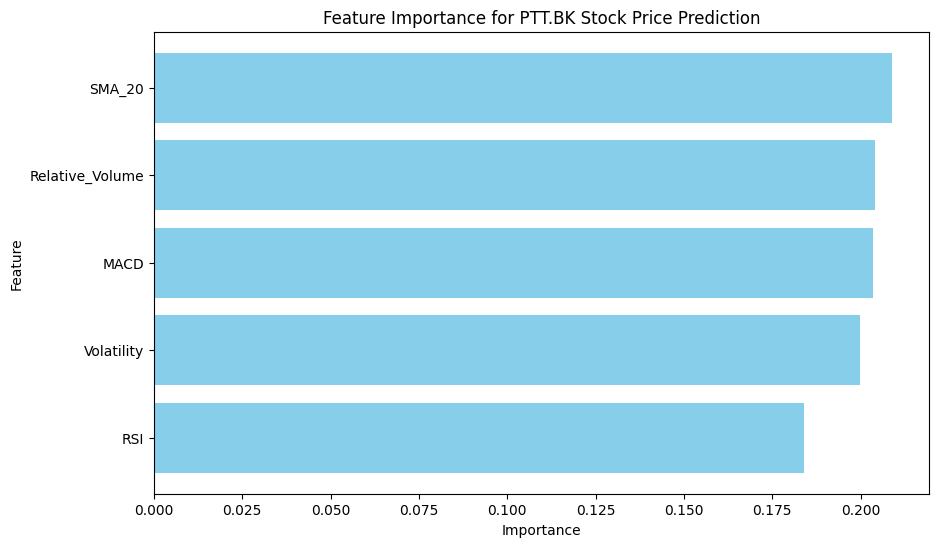

In [20]:
feature_importances = modelRF_PTT.feature_importances_

feature_names = X_train.columns

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importances
})


importance_df = importance_df.sort_values(by='Importance', ascending=False)

print("Feature Importances:")
print(importance_df)

plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='skyblue')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Feature Importance for PTT.BK Stock Price Prediction')
plt.gca().invert_yaxis()
plt.show()

Random Forest (PTT) : <br>
MACD = 0.205 <br>
Volatility = 0.204 <br>
Relative Volume = 0.203 <br>
SMA = 0.199 <br>
RSI = 0.187<br>
Accuracy = 62%

จากการวิเคราะห์ Feature Importance พบว่าโมเดลให้ความสำคัญกับ MACD และ Volatility สูงที่สุด สะท้อนให้เห็นว่าราคาหุ้น PTT มีพฤติกรรมเคลื่อนที่ตามแนวโน้มแรงเฉื่อย (Trend-Following) และมีความไวต่อสภาวะความเสี่ยงในตลาด ดังนั้นการพยากรณ์ด้วยเทคนิคเพียงอย่างเดียวอาจไม่เพียงพอ จำเป็นต้องนำข้อมูลเชิงคุณภาพ (Qualitative Data) เช่น ข่าวเศรษฐกิจมหภาคและราคาน้ำมันโลกมาวิเคราะห์ร่วมด้วย เพื่อลดช่องว่างความผิดพลาดในช่วงที่ตลาดมีความผันผวนสูงผิดปกติ

##XGBoost For PTT

In [21]:
from xgboost import XGBClassifier

In [22]:
modelXG_PTT = XGBClassifier(n_estimators=100, random_state=42)
modelXG_PTT.fit(X_train, y_train)

X_test = test_df[['Relative_Volume','RSI', 'MACD', 'SMA_20', 'Volatility']]
y_predRF_PTT = modelXG_PTT.predict(X_test)


In [23]:
print("--- Evaluation Report ---")
print(classification_report(y_test, y_predRF_PTT))

--- Evaluation Report ---
              precision    recall  f1-score   support

           0       0.63      0.91      0.74       148
           1       0.42      0.11      0.18        88

    accuracy                           0.61       236
   macro avg       0.52      0.51      0.46       236
weighted avg       0.55      0.61      0.53       236



Feature Importances:
           Feature  Importance
2             MACD    0.211816
3           SMA_20    0.203444
4       Volatility    0.197870
0  Relative_Volume    0.193816
1              RSI    0.193054


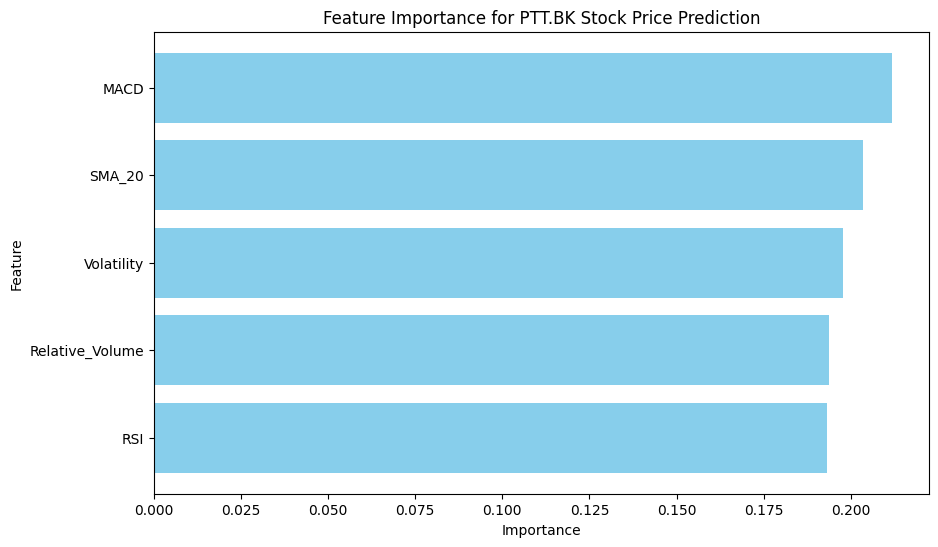

In [24]:
feature_importances = modelXG_PTT.feature_importances_

feature_names = X_train.columns

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importances
})

importance_df = importance_df.sort_values(by='Importance', ascending=False)

print("Feature Importances:")
print(importance_df)

plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='skyblue')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Feature Importance for PTT.BK Stock Price Prediction')
plt.gca().invert_yaxis()
plt.show()

XGBoost (PTT) : <br>
SMA = 0.221 <br>
MACD = 0.215 <br>
RSI = 0.202 <br>
Relative Volume = 0.191 <br>
Volatility = 0.169 <br>
Accuracy = 61%

จากการวัด Accuracy RandomForest มีความแม่นยำกว่า แต่ในตัวของ XGBoost กลับให้ความสำคัญกับ SMA และ RSI ด้วย ซึ่งเป็นเครื่องมือในการวัดเทรนและ การซื้อ-ขาย ของหุ้นที่มากเกินหรือน้อยเกิน ทำให้เราสามารถจับสังเกตุและนำไปใช้งานต่อได้ง่ายกว่า แม้ RSI จะเป็นอันดับ 3 แต่ MACD ก็เป็นอันดับ 2 ทำให่เรายังจำเป็นต้องจับจังหวะการแกว่งตัวของราคาอยู่บ้าง

####สนใจหุ้น KBANK

In [25]:
df_kbank_full = yf.download("KBANK.BK", period="5y")
df_kbank_full = df_kbank_full.xs('KBANK.BK', axis=1, level=1)
df_kbank_full

/tmp/ipykernel_13665/1974678290.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df_kbank_full = yf.download("KBANK.BK", period="5y")
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Date,,,,,
2021-04-12,111.999969,114.425962,111.595637,114.021630,18151500
2021-04-16,108.765335,110.382663,107.552339,109.978331,33938200
2021-04-19,110.786995,110.786995,108.765334,109.573999,20513200
2021-04-20,115.317291,116.964681,109.139579,111.198817,37233200
2021-04-21,115.317291,115.729139,113.669901,114.905444,21384700
...,...,...,...,...,...
2026-04-03,190.500000,192.000000,190.000000,192.000000,11180200
2026-04-07,191.500000,192.000000,190.000000,191.000000,6165500
2026-04-08,193.000000,194.000000,192.500000,193.000000,11115400


<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

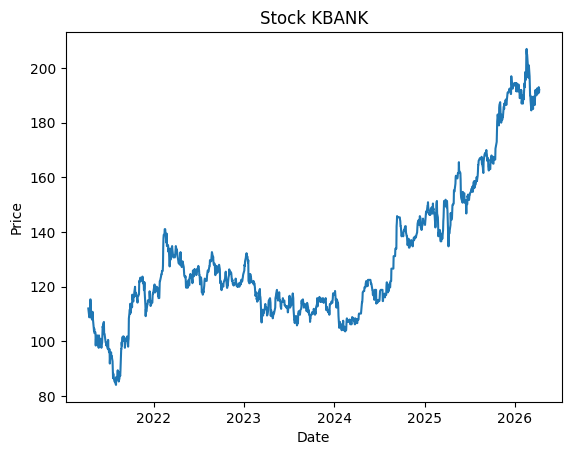

In [26]:
plt.plot(df_kbank_full['Close'])
plt.title('Stock KBANK')
plt.xlabel('Date')
plt.ylabel('Price')
plt

In [27]:
df_kbank = df_kbank_full.copy()
df_kbank.rename(columns={"KBANK.BK": "Close"}, inplace=True)

# RSI (Relative Strength Index)
df_kbank['RSI'] = ta.rsi(df_kbank['Close'], length=14)

# MACD (Moving Average Convergence Divergence)
macd_kbank = ta.macd(df_kbank['Close'])
df_kbank['MACD'] = macd_kbank['MACD_12_26_9']
df_kbank['MACD_Signal'] = macd_kbank['MACDs_12_26_9']

# MA (Moving Average) - ใช้ Simple Moving Average 20 วัน

df_kbank['SMA_20'] = ta.sma(df_kbank['Close'], length=20)

# Volatility (ใช้ Standard Deviation ของ Close prices)
df_kbank['Volatility'] = df_kbank['Close'].rolling(window=20).std()

df_kbank['Vol_SMA'] = df_kbank['Volume'].rolling(window=20).mean()
df_kbank['Relative_Volume'] = df_kbank['Volume'] / df_kbank['Vol_SMA']

# 3. กำหนด Target (Y)
# พยากรณ์ว่า "พรุ่งนี้" ราคาปิดจะสูงกว่า "วันนี้" หรือไม่
# 1 = ขึ้น, 0 = ลง หรือ เท่าเดิม
df_kbank['Target'] = (df_kbank['Close'].shift(-1) > df_kbank['Close']).astype(int)
df_kbank.drop(['High', 'Low','Open'], axis=1, inplace=True)

# 4. ทำความสะอาดข้อมูล (ลบแถวที่มีค่า NaN จากการคำนวณ Indicator)
df_kbank.dropna(inplace=True)

# แสดงตัวอย่างข้อมูล
print(df_kbank.head())

Price            Close    Volume        RSI      MACD  MACD_Signal  \
Date                                                                 
2021-06-07   99.667114  30478500  37.988020 -2.961492    -3.556395   
2021-06-08  102.550041  48686900  44.316883 -2.516768    -3.348470   
2021-06-09  105.432968  70033900  49.830934 -1.909679    -3.060712   
2021-06-10  105.021133  51261200  49.083188 -1.445130    -2.737595   
2021-06-11  106.256676  22388700  51.437559 -0.966136    -2.383304   

Price           SMA_20  Volatility     Vol_SMA  Relative_Volume  Target  
Date                                                                     
2021-06-07  100.202510    1.822838  37142735.0         0.820578       1  
2021-06-08  100.181918    1.792092  37979535.0         1.281925       1  
2021-06-09  100.284879    2.028664  40594495.0         1.725207       0  
2021-06-10  100.387841    2.215350  42068550.0         1.218516       1  
2021-06-11  100.779097    2.521511  40667960.0         0.550524  

In [28]:
df_kbank.columns

Index(['Close', 'Volume', 'RSI', 'MACD', 'MACD_Signal', 'SMA_20', 'Volatility',
       'Vol_SMA', 'Relative_Volume', 'Target'],
      dtype='str', name='Price')

In [29]:
split_index = int(len(df_kbank) * 0.8)
train_df = df_kbank.iloc[:split_index]
test_df = df_kbank.iloc[split_index:]

X_train = train_df[['Relative_Volume','RSI', 'MACD', 'SMA_20', 'Volatility']]
y_train = train_df['Target']

X_test = test_df[['Relative_Volume','RSI', 'MACD', 'SMA_20', 'Volatility']]
y_test = test_df['Target']

In [30]:
print(f"จำนวนข้อมูล Train: {len(X_train)} วัน")
print(f"จำนวนข้อมูล Test: {len(X_test)} วัน")

จำนวนข้อมูล Train: 942 วัน
จำนวนข้อมูล Test: 236 วัน


##Random Forest (KBank)

In [31]:
modelRF_kbank = RandomForestClassifier(n_estimators=100, random_state=42)
modelRF_kbank.fit(X_train, y_train)

X_test = test_df[['Relative_Volume','RSI', 'MACD', 'SMA_20', 'Volatility']]
y_predRF_kbank = modelRF_kbank.predict(X_test)

In [32]:
print("--- Evaluation Report ---")
print(classification_report(y_test, y_predRF_kbank))

--- Evaluation Report ---
              precision    recall  f1-score   support

           0       0.56      0.89      0.69       131
           1       0.48      0.13      0.21       105

    accuracy                           0.55       236
   macro avg       0.52      0.51      0.45       236
weighted avg       0.53      0.55      0.47       236



Feature Importances:
           Feature  Importance
4       Volatility    0.219252
1              RSI    0.201564
2             MACD    0.199565
3           SMA_20    0.192421
0  Relative_Volume    0.187197


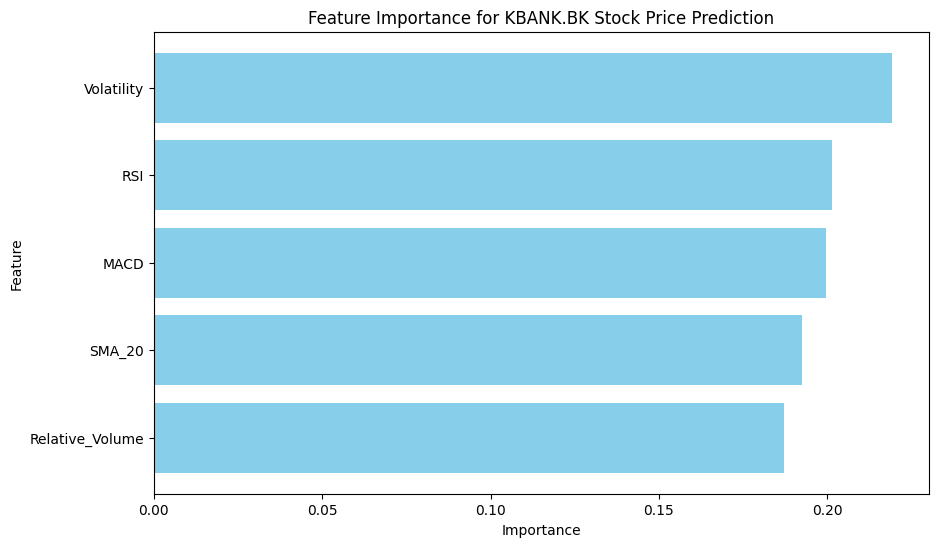

In [33]:
feature_importances = modelRF_kbank.feature_importances_

feature_names = X_train.columns

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importances
})

importance_df = importance_df.sort_values(by='Importance', ascending=False)

print("Feature Importances:")
print(importance_df)

plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='skyblue')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Feature Importance for KBANK.BK Stock Price Prediction')
plt.gca().invert_yaxis()
plt.show()

Random Forest (Kbank) : <br>
Volatility = 0.220 <br>
MACD = 0.1997 <br>
RSI = 0.1994 <br>
SMA = 0.193 <br>
Relative Volume = 0.187 <br>
Accuracy = 55%

โมเดล RandomForest พยากรณ์ PTT ได้แม่นยำกว่า KBANK (61% vs 56%) เนื่องจาก PTT มีทิศทางตามราคาน้ำมันและเทรนที่ชัดเจนกว่า ขณะที่ KBANK ให้ความสำคัญกับ Volatility สูงที่สุด สะท้อนถึงความไวต่อสภาวะความเสี่ยงของระบบเศรษฐกิจ ซึ่งเป็นปัจจัยที่มีความซับซ้อนและมี Noise สูงกว่า เนื่องจากยังมีตัวแปรที่ไม่ได้นำเข้ามานับเช่น ค่าเงินบาท, นโยบายธนาคารกลาง (Bot) หรือภาพรวมเศรษฐกิจ เป็นต้น

##XGBoost (KBank)

In [34]:
modelXG_kbank = XGBClassifier(n_estimators=100, random_state=42)
modelXG_kbank.fit(X_train, y_train)

X_test = test_df[['Relative_Volume','RSI', 'MACD', 'SMA_20', 'Volatility']]
y_predXG_kbank = modelXG_kbank.predict(X_test)


In [35]:
print("--- Evaluation Report ---")
print(classification_report(y_test, y_predXG_kbank))

--- Evaluation Report ---
              precision    recall  f1-score   support

           0       0.55      0.94      0.69       131
           1       0.27      0.03      0.05       105

    accuracy                           0.53       236
   macro avg       0.41      0.48      0.37       236
weighted avg       0.42      0.53      0.41       236



Feature Importances:
           Feature  Importance
2             MACD    0.215445
0  Relative_Volume    0.201025
4       Volatility    0.200491
1              RSI    0.194467
3           SMA_20    0.188572


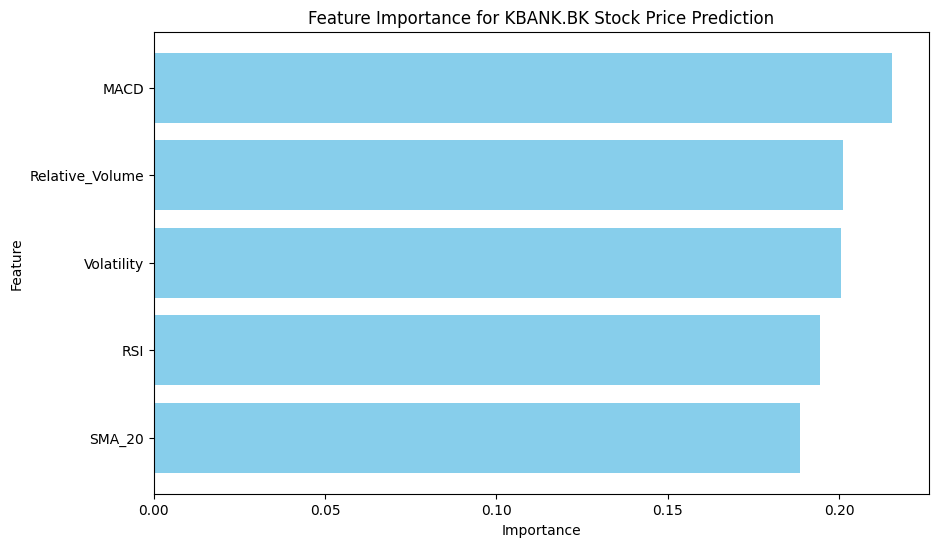

In [36]:
feature_importances = modelXG_kbank.feature_importances_

feature_names = X_train.columns

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importances
})

importance_df = importance_df.sort_values(by='Importance', ascending=False)

print("Feature Importances:")
print(importance_df)

plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='skyblue')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Feature Importance for KBANK.BK Stock Price Prediction')
plt.gca().invert_yaxis()
plt.show()

XGBoost (Kbank) : <br>
MACD = 0.214 <br>
Volatility = 0.202 <br>
SMA = 0.198 <br>
RSI = 0.195 <br>
Relative Volume = 0.188 <br>
Accuracy = 53%

สำหรับหุ้น KBANK ทั้งสองโมเดลให้ผลลัพธ์ใกล้เคียงกันที่ 55-56% โดยมีค่าความสำคัญของตัวแปรเกาะกลุ่มกันชัดเจนในด้าน Momentum (MACD) และ ความเสี่ยง (Volatility) ซึ่งสะท้อนพฤติกรรมของหุ้นกลุ่มธนาคารที่เคลื่อนไหวตามสภาวะเศรษฐกิจ อย่างไรก็ตาม ความแม่นยำที่น้อยกว่าหุ้นกลุ่มอื่นแสดงให้เห็นว่า ปัจจัยทางเทคนิคเพียงอย่างเดียวอาจไม่เพียงพอ การเพิ่มตัวแปรด้านมหภาค เช่น อัตราดอกเบี้ย หรือ Yield Curve อาจช่วยเพิ่มประสิทธิภาพในการพยากรณ์ได้มากกว่านี้

###สนใจหุ้น CPALL

In [37]:
df_cpall_full = yf.download("CPALL.BK", period="5y")
df_cpall_full = df_cpall_full.xs('CPALL.BK', axis=1, level=1)
df_cpall_full

/tmp/ipykernel_13665/2294739579.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df_cpall_full = yf.download("CPALL.BK", period="5y")
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Date,,,,,
2021-04-12,58.885818,60.040442,58.654894,59.809518,32020800
2021-04-16,59.116745,59.578595,58.654895,59.347670,31473500
2021-04-19,59.347668,59.809517,59.116743,59.116743,18793100
2021-04-20,60.040443,60.271368,59.347669,59.578594,27266700
2021-04-21,59.347668,60.040442,59.347668,59.809517,13111200
...,...,...,...,...,...
2026-04-03,45.500000,46.250000,45.500000,45.750000,33660300
2026-04-07,45.250000,45.500000,45.000000,45.500000,20459900
2026-04-08,47.250000,47.500000,46.000000,46.500000,50052800


<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

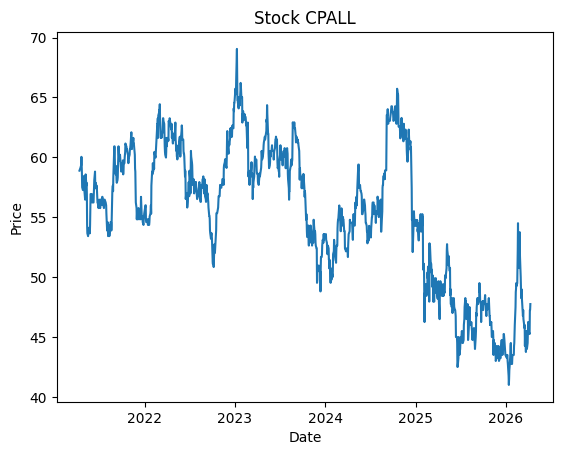

In [38]:
plt.plot(df_cpall_full['Close'])
plt.title('Stock CPALL')
plt.xlabel('Date')
plt.ylabel('Price')
plt

In [39]:
df_cpall = df_cpall_full.copy()
df_cpall.rename(columns={"CPALL.BK": "Close"}, inplace=True)

# RSI (Relative Strength Index)
df_cpall['RSI'] = ta.rsi(df_cpall['Close'], length=14)

# MACD (Moving Average Convergence Divergence)
macd_cpall = ta.macd(df_cpall['Close'])
df_cpall['MACD'] = macd_cpall['MACD_12_26_9']
df_cpall['MACD_Signal'] = macd_cpall['MACDs_12_26_9']

# MA (Moving Average) - ใช้ Simple Moving Average 20 วัน

df_cpall['SMA_20'] = ta.sma(df_cpall['Close'], length=20)

# Volatility (ใช้ Standard Deviation ของ Close prices)
df_cpall['Volatility'] = df_cpall['Close'].rolling(window=20).std()

df_cpall['Vol_SMA'] = df_cpall['Volume'].rolling(window=20).mean()
df_cpall['Relative_Volume'] = df_cpall['Volume'] / df_cpall['Vol_SMA']

# 3. กำหนด Target (Y)
# พยากรณ์ว่า "พรุ่งนี้" ราคาปิดจะสูงกว่า "วันนี้" หรือไม่
# 1 = ขึ้น, 0 = ลง หรือ เท่าเดิม
df_cpall['Target'] = (df_cpall['Close'].shift(-1) > df_cpall['Close']).astype(int)
df_cpall.drop(['High', 'Low','Open'], axis=1, inplace=True)

# 4. ทำความสะอาดข้อมูล (ลบแถวที่มีค่า NaN จากการคำนวณ Indicator)
df_cpall.dropna(inplace=True)

# แสดงตัวอย่างข้อมูล
print(df_cpall.head())

Price           Close    Volume        RSI      MACD  MACD_Signal     SMA_20  \
Date                                                                           
2021-06-07  56.231686  11574800  51.542729 -0.609019    -1.162890  55.622509   
2021-06-08  56.231686  17748400  51.542729 -0.544844    -1.039281  55.505359   
2021-06-09  56.934578  19272900  56.512636 -0.432284    -0.917882  55.470214   
2021-06-10  57.871777  31085400  62.094947 -0.264408    -0.787187  55.470214   
2021-06-11  58.106075  21782500  63.361185 -0.111177    -0.651985  55.528789   

Price       Volatility     Vol_SMA  Relative_Volume  Target  
Date                                                         
2021-06-07    1.708934  31577160.0         0.366556       0  
2021-06-08    1.570618  30846170.0         0.575384       1  
2021-06-09    1.527675  31014075.0         0.621424       1  
2021-06-10    1.527675  31628785.0         0.982820       1  
2021-06-11    1.607168  31758960.0         0.685869       1  


In [40]:
df_cpall.columns

Index(['Close', 'Volume', 'RSI', 'MACD', 'MACD_Signal', 'SMA_20', 'Volatility',
       'Vol_SMA', 'Relative_Volume', 'Target'],
      dtype='str', name='Price')

In [41]:
split_index = int(len(df_cpall) * 0.8)
train_df = df_cpall.iloc[:split_index]
test_df = df_cpall.iloc[split_index:]

X_train = train_df[['Relative_Volume','RSI', 'MACD', 'SMA_20', 'Volatility']]
y_train = train_df['Target']

X_test = test_df[['Relative_Volume','RSI', 'MACD', 'SMA_20', 'Volatility']]
y_test = test_df['Target']

In [42]:
print(f"จำนวนข้อมูล Train: {len(X_train)} วัน")
print(f"จำนวนข้อมูล Test: {len(X_test)} วัน")

จำนวนข้อมูล Train: 942 วัน
จำนวนข้อมูล Test: 236 วัน


Random Forest (CPALL)

In [43]:
modelRF_cpall = RandomForestClassifier(n_estimators=100, random_state=42)
modelRF_cpall.fit(X_train, y_train)

X_test = test_df[['Relative_Volume','RSI', 'MACD', 'SMA_20', 'Volatility']]
y_predRF_cpall = modelRF_cpall.predict(X_test)

In [44]:
print("--- Evaluation Report ---")
print(classification_report(y_test, y_predRF_cpall))

--- Evaluation Report ---
              precision    recall  f1-score   support

           0       0.54      0.43      0.48       134
           1       0.41      0.53      0.46       102

    accuracy                           0.47       236
   macro avg       0.48      0.48      0.47       236
weighted avg       0.49      0.47      0.47       236



Feature Importances:
           Feature  Importance
1              RSI    0.203310
4       Volatility    0.203027
3           SMA_20    0.200375
0  Relative_Volume    0.199421
2             MACD    0.193868


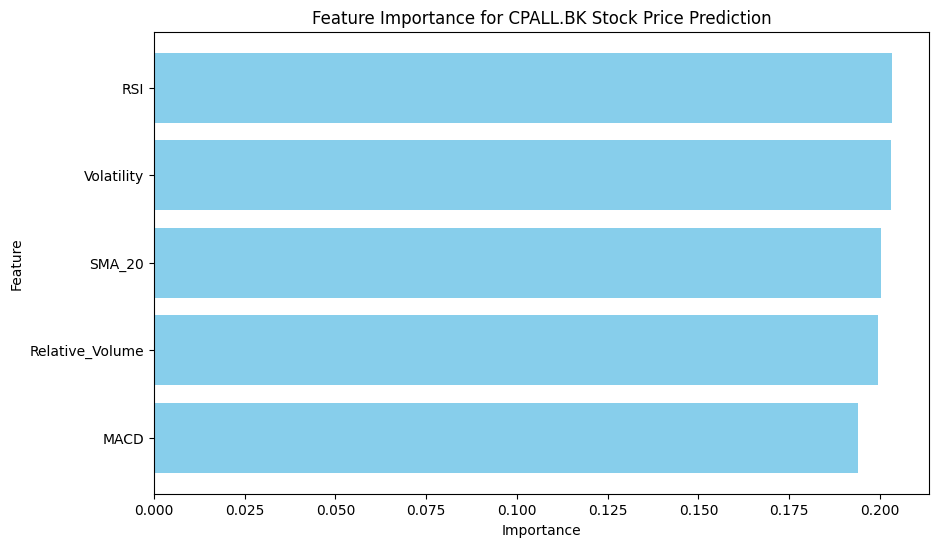

In [45]:
feature_importances = modelRF_cpall.feature_importances_

feature_names = X_train.columns

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importances
})

importance_df = importance_df.sort_values(by='Importance', ascending=False)

print("Feature Importances:")
print(importance_df)

plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='skyblue')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Feature Importance for CPALL.BK Stock Price Prediction')
plt.gca().invert_yaxis()
plt.show()

Random Forest (Cpall) : <br>
Volatility = 0.203 <br>
MACD = 0.193 <br>
RSI = 0.202 <br>
SMA = 0.201 <br>
Relative Volume = 0.199 <br>
Accuracy = 47%

จากการทดสอบกับหุ้น CPALL พบว่าโมเดลให้ความแม่นยำเพียง 47% ซึ่งต่ำกว่าหุ้นในกลุ่มพลังงานและธนาคาร สะท้อนให้เห็นว่า พฤติกรรมราคาของหุ้นกลุ่มค้าปลีกมีความซับซ้อนและไม่ได้เคลื่อนที่ตามปัจจัยทางเทคนิคเป็นหลัก (Non-technical driven) โดยค่า Feature Importance ที่เกาะกลุ่มกันอย่างใกล้ชิดบ่งบอกว่าไม่มีอินดิเคเตอร์ตัวใดตัวหนึ่งที่สามารถเป็นตัวชี้นำราคาได้ชัดเจน (Lack of leading indicators) ดังนั้นในหุ้นลักษณะนี้ การใช้เพียง Technical Analysis จึงไม่เพียงพอ และจำเป็นต้องเพิ่มตัวแปรด้านเศรษฐกิจมหภาคหรือข้อมูลการบริโภคในประเทศเข้ามาเสริมเพื่อให้โมเดลเรียนรู้ Pattern ได้ดียิ่งขึ้น

##XGBoost (CPALL)

In [46]:
modelXG_cpall = XGBClassifier(n_estimators=100, random_state=42)
modelXG_cpall.fit(X_train, y_train)

X_test = test_df[['Relative_Volume','RSI', 'MACD', 'SMA_20', 'Volatility']]
y_predXG_cpall = modelXG_cpall.predict(X_test)


In [47]:
print("--- Evaluation Report ---")
print(classification_report(y_test, y_predXG_cpall))

--- Evaluation Report ---
              precision    recall  f1-score   support

           0       0.57      0.54      0.56       134
           1       0.44      0.46      0.45       102

    accuracy                           0.51       236
   macro avg       0.50      0.50      0.50       236
weighted avg       0.51      0.51      0.51       236



Feature Importances:
           Feature  Importance
1              RSI    0.214310
4       Volatility    0.204471
3           SMA_20    0.199888
0  Relative_Volume    0.192955
2             MACD    0.188377


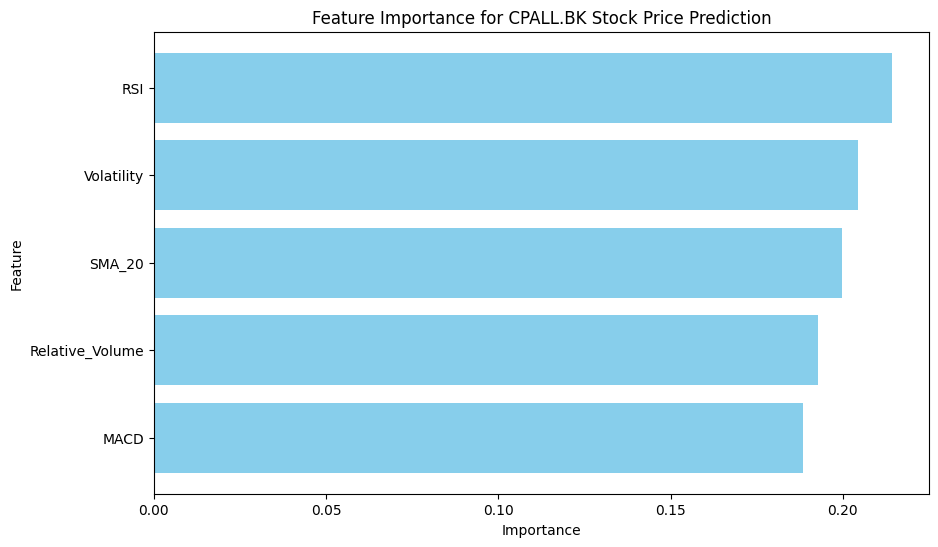

In [48]:
feature_importances = modelXG_cpall.feature_importances_

feature_names = X_train.columns

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importances
})

importance_df = importance_df.sort_values(by='Importance', ascending=False)

print("Feature Importances:")
print(importance_df)

plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='skyblue')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Feature Importance for CPALL.BK Stock Price Prediction')
plt.gca().invert_yaxis()
plt.show()

XGBoost (Cpall) : <br>
RSI = 0.209 <br>
SMA = 0.200 <br>
Relative Volume = 0.197 <br>
Volatility = 0.198 <br>
MACD = 0.193 <br>
Accuracy = 51%

แม้ CPALL จะมีความผันผวนของราคาที่จับทางได้ยากในระยะสั้น แต่การที่ RSI และ SMA พุ่งขึ้นมาเป็นปัจจัยหลักในโมเดล XGBoost แสดงให้เห็นว่าหุ้นตัวนี้ยังคงเคลื่อนที่ตามปัจจัยทางเทคนิคพื้นฐาน (Technical Driven) ในระดับหนึ่ง โดยเฉพาะจังหวะการย่อตัวเพื่อไปต่อตามแนวโน้มเดิม

จากการศึกษาพบว่าหุ้นในแต่ละกลุ่มอุตสาหกรรมมีพฤติกรรมข้อมูลที่ต่างกัน หุ้นที่มีความสัมพันธ์กับปัจจัยภายนอกชัดเจนอย่าง PTT สามารถพยากรณ์ได้แม่นยำที่สุด ในขณะที่หุ้นกลุ่มค้าปลีกอย่าง CPALL มีความซับซ้อนสูงกว่าและจำเป็นต้องใช้โมเดลขั้นสูงอย่าง XGBoost เพื่อจับสัญญาณการกลับตัว (RSI) และแนวโน้ม (SMA) จึงจะให้ผลลัพธ์ที่มีนัยสำคัญ